<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_4/Chapter04/training_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Training Models

## Linear Regression

For a model with $n$ input features $x_1, x_2, \dots, x_n$:
$$
\hat{y} = 	\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$
or, in vector form:
$$
\hat{y} = h_\theta(x) = \theta \cdot x
$$
where:
- $\hat{y}$ = predicted value
- $h_\theta$ = hypothesis function
- $\theta$ = parameter vector, contain the bias term (intercept) $\theta_0$ and feature weights $\theta_1, \theta_2, \cdots, \theta_n$
- $x$ = feature vector, $x_0, x_1, x_2, \cdots, x_n$, where $x_0$ is always equal to 1
- $\theta \cdot x$ = $\theta_0x_0 + \theta_1x_1 + \theta_2x_2 + \cdots + \theta_n x_n$

### The Normal Equation

- Unlike the iterative gradient descent methods, the Normal Equation provides a closed-form analytical solution to find the optimal parameters in a single step using matrix operations
- Efficient for small to medium-sized datasets with a manageable number of features but becomes computationally expensive when dealing with very large datasets due to the need for matrix inversion

$$
\hatθ = (X^TX)^{-1} X^T y
$$
where:
- $\hatθ$ = value of $θ$ that minimizes the cost function
- $y$ = vector of target values

Purpose:
- Find the parameter vector (the weights that the model learn) of a linear regression model that minimizes the cost function (MSE)
- The optimal parameter $\hatθ$:
  $$
  \mathbf{\hatθ} = \begin{pmatrix}
  \theta_0 \\
  \theta_1 \\
  \theta_2 \\
  \vdots \\
  \theta_n
  \end{pmatrix}
  $$

  - $\theta_0$ is the intercept
  - Slope coefficients $\theta_1, \theta_2, … , \theta_n$

In [1]:
import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)
y = 4 + 3 * X + np.random.randn(m,1)

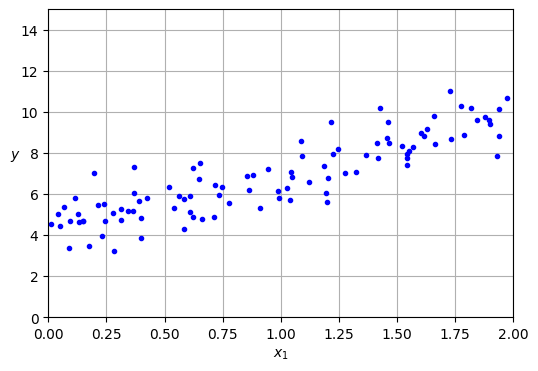

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

- Compute $\hatθ$ using normal equation

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Intercept (bias) is 4.215
# Slope is 2.770
theta_best

array([[4.21509616],
       [2.77011339]])

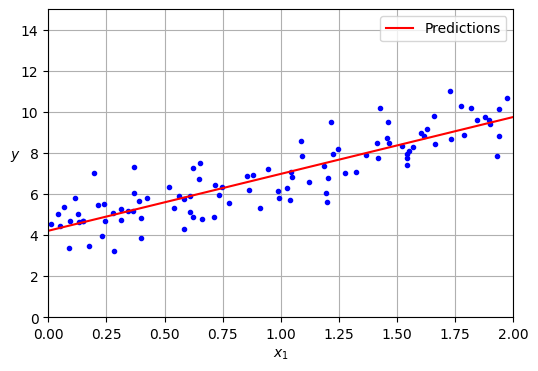

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend()
plt.show()

In [5]:
# All the background explanations above can be simplified by using Scikit-Learn linear regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [6]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

## Gradient Descent

- Generic optimization algorithm
- Tweak **parameters** iteratively to minimize cost function (MSE)
- Recommended Video: https://youtu.be/sDv4f4s2SB8?si=6H_AZ2aUpq1M1Lxl

1. Why is Mean Squared Error (MSE) cost function in paraboloid (bowl-shaped / U-shaped)?
   $$
   MSE = \frac{1}{m} \sum_{i=1}^{m} (Predicted_i - Actual_i)^2
   = \frac{1}{m} \sum_{i=1}^{m} (θ^Tx^{(i)} - y^{(i)})^2
   $$
   - It is a quadratic function of the model's parameters
   - Quadratic: something that relates to or is characterized by squares
   - Cost function graph of model with 1 parameter ($θ$) forms a simple parabola (2D U-shape)
   - Cost function graph of multiple parameters forms a multi-dimensional bowl shape

2. When will MSE cost function not form a paraboloid?
   - When using MSE to evaluate non-linear model
   - Data is insufficient or ill-conditioned

3. Is polynomial regression considered non-linear to form non-paraboloid plot?
   - Yes, however there is an important nuance in machine learning
   - Polynomial regression is considered linear regression model because it is linear in terms of the parameters ($θ$)
   - As long as the model is in the form of $\hat{y}= θ_0​f_0​(x) + θ_1​f_1​(x) + \cdots $ , where $f_i(x)$ can be any function of $x$ (like $x^2, sin⁡(x), log(x)$, the model is linear regression, because it’s linear in $θ$.

### Batch Gradient Descent

In [7]:
eta = 0.1 # Learning Rate
n_epochs = 1000
m = len(X_b)  # Number of instances

np.random.seed(42)
theta = np.random.randn(2,1)  # Randomly initialized model parameters

for epoch in range(n_epochs):
  gradients = 2 / m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

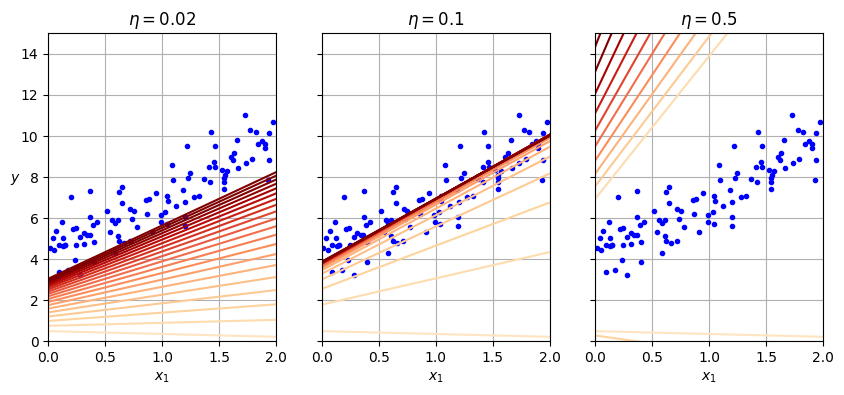

In [8]:
# Plot the first 20 steps of gradient descent using different learning rates

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # Random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
plt.show()

### Stochastic Gradient Descent

What is the difference between batch gradient descent and stochastic gradient descent?
- batch gradient descent (BGD) uses the whole training set to compute the gradients at every step
- stochastic gradient descent (SGD) picks a random instance in the training set at every step and computes the gradients based only on that single instance
- SGD cost function is very irregular, has a better chance of finding the global minimum than BGD
- SGD randomness can help to escape from local optima but it can never settle at the minimum

Solution to SGD dilemma
- gradually reduce the learning rate (*learning schedule*)

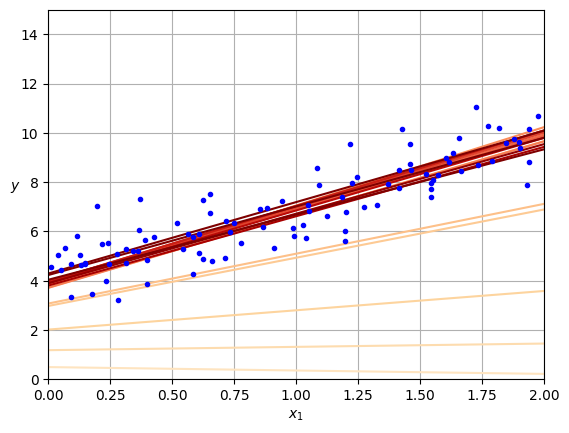

array([[4.21076011],
       [2.74856079]])

In [9]:
# Implement SGD with simple learning schedule

n_epochs = 50
t0, t1 = 5, 50  # Learning schedule hyperparameters
theta_path_sgd = []
n_shown = 20

def learning_schedule(t):
  return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2,1)  # Random initialization

for epoch in range(n_epochs):
  for iteration in range(m):

    if epoch == 0 and iteration < n_shown:
      y_predict = X_new_b @ theta
      color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
      plt.plot(X_new, y_predict, color=color)

    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(epoch * m + iteration)
    theta = theta - eta * gradients
    theta_path_sgd.append(theta)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

theta

- The figure shows the first 20 steps of training and how irregular the steps are

In [10]:
# Scikit-Learn SGDRegressor class, defaults to optimizing the MSE cost function

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

sgd_reg.intercept_, sgd_reg.coef_

(array([4.15474433]), array([2.82564538]))

### Mini-Batch Gradient Descent

- Computes the gradients on small random sets of instances

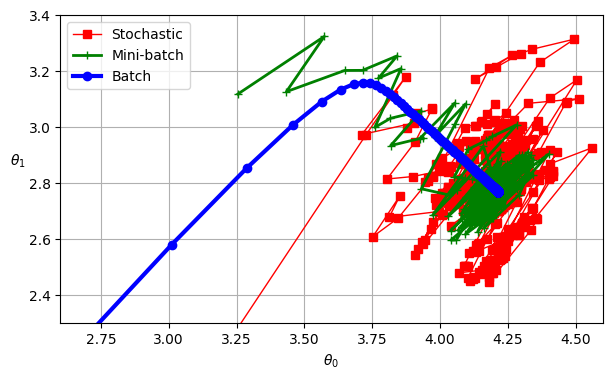

In [11]:
from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
plt.show()

## Polynomial Regression

- Using linear model to fit nonlinear data
- As discussed above, as long as the model is linear in terms of the parameters, it is a linear model
- Add powers of each feature as new features

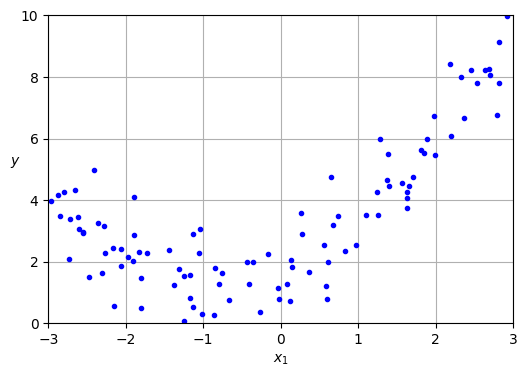

In [12]:
# Generate nonlinear data using simple quadratic equation y = ax2 + bx + c

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m,1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

In [13]:
# Use PolynomialFeatures class to transform training data
# By adding the square of each feature in the training set as a new feature

from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Original feature
print(X[0])

# Original feature plus the square of the feature
print(X_poly[0])

[-0.75275929]
[-0.75275929  0.56664654]


In [14]:
# Fit using LinearRegression model

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

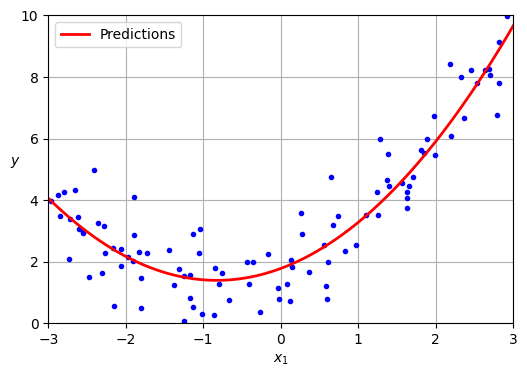

In [15]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

Orginal
- $y = 0.5x_1^2 + x_1 + 2 + $ Gaussian noise

Predicted
- $\hat y = 0.56x_1^2 + 0.93x_1 + 1.78$

PolynomialFeatures(degree=$d$) transforms an array containing $n$ features into an array containing ($n + d$)! features

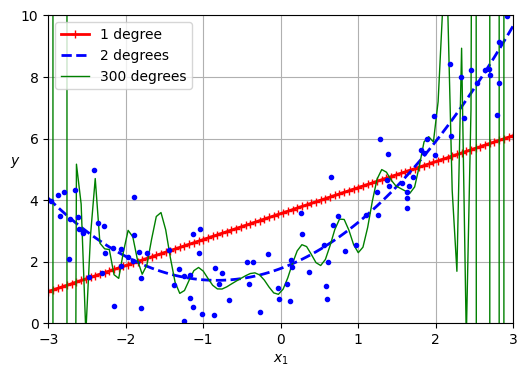

In [16]:
# Compares with pure linear model, quadratic model, and 300-degree polynomial model
# 300-degree polynomial model wiggles around the instances, showing that the model is severely overfitting the training data
# Linear model is underfitting

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

## Learning Curves

In Chapter 02, we use cross-validation to estimate the model's generalization performance
- If model performs well on training data but generalizes poorly on the cross-validation metrics → overfitting
- Performs poorly on both → underfitting

Another way to measure performance, is by looking at *learning curves*

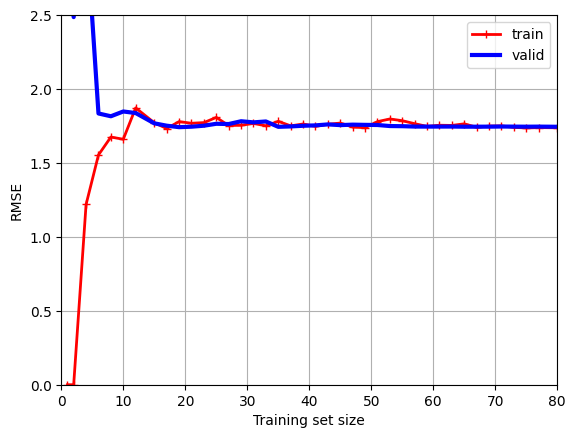

In [17]:
# Learning curves of the plain linear regression model

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1, 40), cv=5, scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

- Training error
  - Initially when there are just one or two instances in the training set, the model can fit perfectly
  - As new instances added, the model unable to fit the data perfectly because data is noisy and not linear
  
- Validation error
  - Initially when the model is trained on very few training instances, the error is quite large
  - As the model learns, the error slowly goes down until plateau

- To Improve
  - Use better model
  - Come up with better features
  - Adding more training data will not help

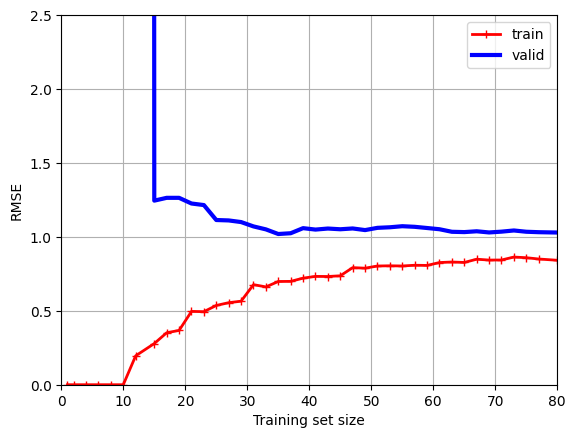

In [18]:
# Learning curves of a 10th-degree polynomial model

from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1, 40), cv=5, scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

- Error on the training data is much lower
- Gap between the curves
- Model performs significantly better on the training data than on the validation data
- To Improve
  - Increase training data until validation error approaches the training error

<ins> Bias / Variance Trade-Off	</ins>

When a model make predictions, total error can be broken into:
1. Bias
   - How wrong are you on average?
   - Error that comes from making the model too simple
   - Underfit
   - Different from the bias term of linear models
2. Variance
   - How sensitive are you to the training data?
   - Error from the model being too “sensitive” to training data
   - Overfitting
3. Irreducible Error
   - Noise you can’t do anything about
   - Error that cannot reduce, no matter how good the model is


To get the best model, you need the right balance:
- Simpler models → higher bias, lower variance
- Very complex models → lower bias, higher variance

Ideal models find the “sweet spot” between the two.

## Regularized Linear Models

- Regularization is a set of machine learning techniques used to prevent overfitting and improve a model's ability to generalize to new, unseen data
- For linear mode, typically achieved by constraining the weights of the model
- 3 different ways
  - Ridge regression
  - Lasso regression
  - Elastic net regression

### Ridge Regression

- Adds a penalty to keep model weights small
- Prevent overfitting by reducing variance, but increasing bias
- Recommended video: https://youtu.be/Q81RR3yKn30?si=Uc4u3q-9lE_PZkE9

<ins> Analogy </ins>

Think of normal linear regression as a car with no speed limit — it can drive wildly fast (large coefficients) and overreact to bumps (noise in data). Ridge regression adds a speed limit so the model behaves more smoothly.

Ridge regression cost function:
- MSE + Regularization term

$$
J(\theta) = MSE(\theta) + \frac{α}{m} \sum_{i=1}^{m} \theta_i^2
$$

where:
- $\alpha$ = controls regularization strength
- $m$ = number of training examples. For scaling, ensures that both terms (MSE and regularization term) in the cost function are consistently scaled as an average cost per example
  - If $\alpha=0$: same as normal regression (MSE)
  - If $\alpha$ is large: weights shrink toward zero

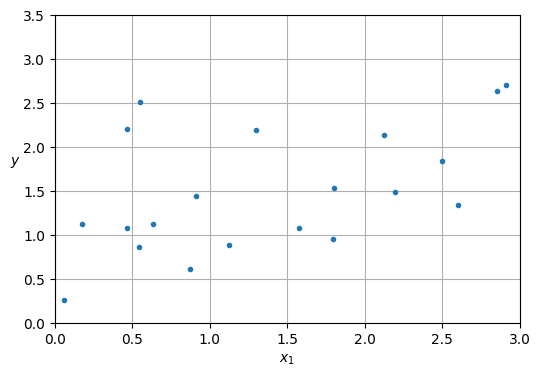

In [19]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

- Ridge regression can be performed by either computing a closed-form equation or by performing gradient descent

In [20]:
# Perform ridge regression with Scikit-Learn using a closed-form solution

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")

ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

In [21]:
# Perform ridge regression with Scikit-Learn using stochastic gradient descent

# Specifying "l2" indicates the you want SGD to add a regularization term
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=1e-2, random_state=42)

sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

- The figure below shows the ridge models trained with different $\alpha$ values
- Increasing $\alpha$ leads to flatter predictions, reducing model's variance but increasing its bias

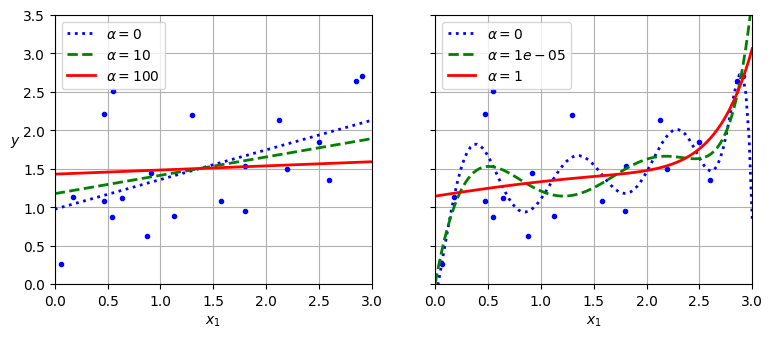

In [22]:
# Linear (left) and polynomial (right) models

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

### Lasso Regression

Lasso regression cost function:
- MSE + Regularization term

$$
J(\theta) = MSE(\theta) + 2\alpha \sum_{i=1}^n \left\vert \theta_i \right\vert
$$

- If  $\alpha = 0$ : same as normal regression (MSE)
- If $\alpha$ is large: weights equal 0

- Recommended video: https://youtu.be/NGf0voTMlcs?si=AqJ3GnvwhrMBDFyj

In [23]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

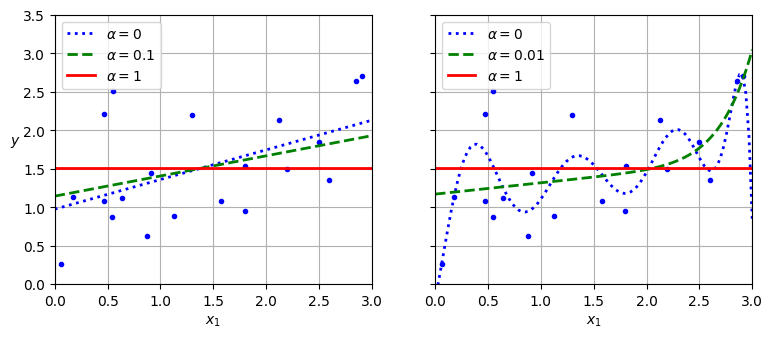

In [24]:
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

1. Differences between lasso and ridge
   - lasso regression eliminates the weights of the least important features
   - ridge regression makes weights smaller, but don’t remove any features
   - lasso regression is useful when you have many features but only a few matter

2. How lasso regression elimates the useless weights
   - For non-zero coefficients $(\theta _{i}\ne 0)$: the derivative of $|\theta _{i}|$ is a constant value: $\frac{\theta_i}{|\theta_i|}$, which is either \(+1\) or \(-1\)
   - For zero coefficients $(\theta _{i}=0)$: The function is not differentiable, which allows for a range of subgradient values (any value between -1 and +1).
   - During optimization (e.g., using gradient descent), the algorithm iteratively updates the coefficients to minimize the total cost
   - Because the L1 penalty has a constant subgradient (±1), it exerts a constant force toward zero. A coefficient becomes exactly zero when the opposing force from the MSE gradient is too small to push it away from zero. This creates the “soft-thresholding” effect that eliminates weak or useless coefficients
  
3. Derivative of $(|\theta _{i}|$)
   $$
   \begin{aligned}
   \frac{d}{d\theta} |\theta| &= \frac{d}{d\theta} \sqrt{\theta^2} \\
   &= \frac{d}{d\theta} (\theta^2)^\frac{1}{2} \\
   &= \frac{1}{2}(\theta^2)^{-\frac{1}{2}} \cdot 2\theta \\
   &= \frac{\theta}{(\theta^2)^\frac{1}{2}} \\
   &= \frac{\theta}{\sqrt{\theta^2}} \\
   &= \frac{\theta_i}{|\theta_i|}
   \end{aligned}
   $$

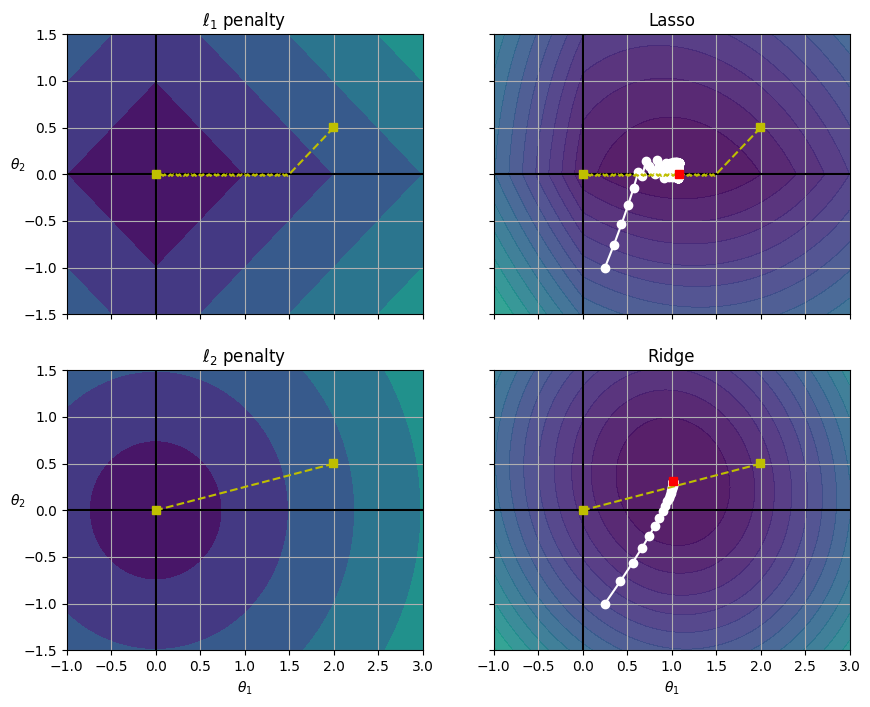

In [25]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.show()

- Axes represent two model parameters
- Background contours represent different loss functions
- Top-left plot
  - Contours represent $\ell_1$ loss $(|\theta_1| + |\theta_2|)$, drops linearly as it gets closer to the axis
  - Only the regularization term
  - Eg. initializing the parameters to $\theta_1 = 2$ and $\theta_2 = 0.5$, running gradient descent will decrement both parameters equally, but $\theta_2$ will reach 0 first (dashed yellow line)
- Top-right plot
  - Contours represent lasso regression's cost function
  - White circle is gradient descent path taken
  - Parameters were initializes around $\theta_1 = 0.25$ and $\theta_2 = -1$
  - Red square is the global optimum
  - Increasing $\alpha$, will move the global optimum to the left along the dashed yellow line, and vice versa
- Bottom-left plot
  - Countours represent $\ell_2$ loss $(\theta_1^2 + \theta_2^2)$
- Bottom-right plot
  - Contours represent ridge regression's cost function

### Elastic Net Regression

- Middle ground between ridge regression and lasso regression

Elastic Net Regression cost function:
$$
J(\theta) = MSE(\theta) + r (2\alpha \sum_{i=1}^n |\theta_i|) + (1-r)(\frac{\alpha}{m}\sum_{i=1}^n \theta_i^2)
$$

where:
- $r$ = mix ratio
  - when $r = 0$, equivalent to ridge regression
  - when $r = 1$, equivalent to lasso regression

1. When to use elastic net, ridge, lasso, or plain linera regression?
   - almost always preferable to have at least a little bit of regularization
   - generally should avoid plain linear regression
   - default use ridge
   - if only a few features are useful, use lasso or elastic net
   - generally, elastic net is preferred over lasso because lasso may behave eratically when:
     - number of features greater than the number of training instances
     - several features are strongly crrelated

In [26]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

## Early Stopping

- Stop training as soon as the validation error reaches a minimum
- Simple and efficient regularization technique

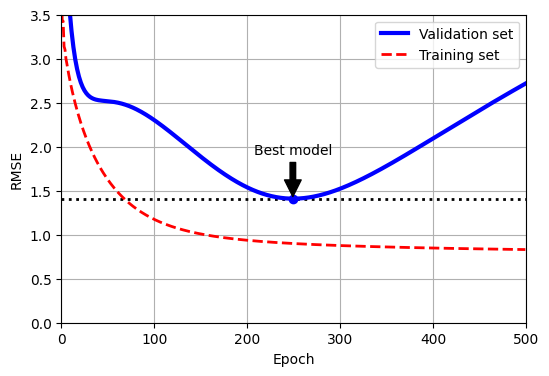

In [27]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False), StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)

    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
plt.show()

## Logistic Regression

- Commonly used to estimate the probability that an instance belongs to a particular class
- Probability greater than threshold will be labeled "1"

### Estimating Probabilities

Logistic regression probability equation:

$$
\begin{aligned}
\hat p &= h_\theta (x) \\
&= \sigma(\theta^Tx)
\end{aligned}
$$

where:
- $\hat p$: probability
- $h_\theta(x)$: hypothesis function (the model) parameterized by $θ$, evaluated at input $x$

Logistic function:

$$
\begin{aligned}
\sigma(\theta^Tx) &= \sigma(t) \\
&= \frac{1}{1 + exp(-t)}
\end{aligned}
$$

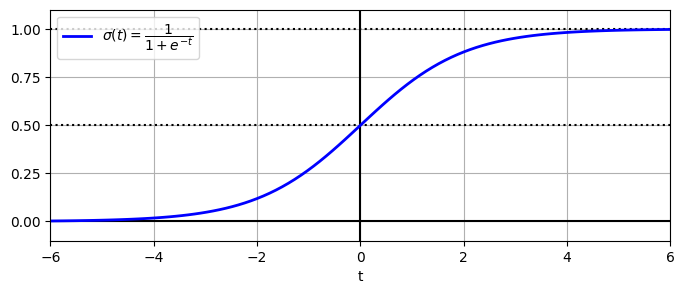

In [28]:
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

### Training and Cost Function

Cost function of a single training instance:

$$
c(\theta) = \begin{cases}
  -log(\hat p) & \text{if } y = 1 \\
  -log(1 - \hat p) & \text{if } y = 0
\end{cases}
$$

Where:
- $y ∈ \{0,1\}$ is the true label
- $\hat p = p(y = 1 | 0,x)$, is the model’s predicted probability that the label is 1
- $\theta$ represents the model parameters

If the true label is 1:
- Cost is $c(\theta) = -log(\hat p)$
- If $\hat p$ (probabiity) is close to 1, cost is small
- If $\hat p$ is close to 0, $log$ of $\hat p$ becomes very large

else if true label is 0:
- Cost is $c(\theta) = -log(1 - \hat p)$
- If $\hat p$ is close to 0, cost is small
- If $\hat p$ is close to 1, cost becomes large

Cost function over the whole training set can be written in single expression called the _log loss_

Logistic regression cost function (log loss):

$$
J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} [y^{(i)}log(\hat p ^ {(i)}) + (1 - y ^ {(i)}) log(1-\hat p ^ {(i)})]
$$


### Decision Boundaries

- Use iris dataset to illustrate logistic regression
- Dataset contains the sepal and petal length and width of 150 iris flowers of 3 different species
  - Iris setosa
  - Iris versicolor
  - Iris virginica

In [29]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

In [30]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [31]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [32]:
# The dataset is not shuffled

iris.target.head(5)

,target
0,0
1,0
2,0
3,0
4,0


In [33]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [34]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [35]:
# Split the data
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


# Train logistic regression model on the training set
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

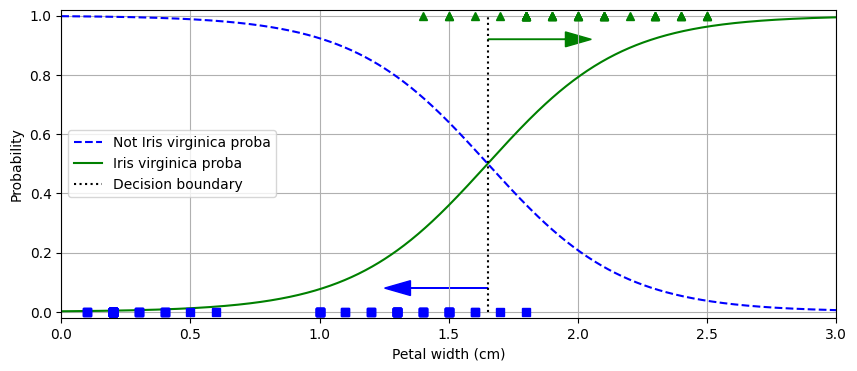

In [36]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(10, 4))
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", label="Decision boundary")

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.show()

- Petal width of Iris virginica flowers (green triangle)  ranges from 1.4cm to 2.5cm
- Other iris flowers (blue squares) ranges from 0.1cm to 1.8cm
- Decision boundary is at around 1.6cm where probabilites for both classes are at 50%

In [37]:
decision_boundary

np.float64(1.6516516516516517)

In [38]:
log_reg.predict([[1.7],[1.5]])

array([ True, False])

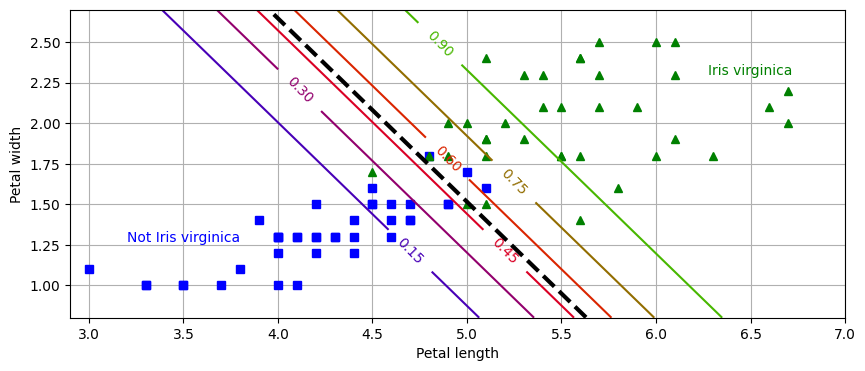

In [39]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1), np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

- Displaying two features: petal width and length
- Dashed line represents the points where the model estimates a 50% probability (decision boundary)
- Each parallel line represents the probability from 15% to 90%
- Logistic regression models can also be regularized using $\ell_1$ and $\ell_2$ penalties
- By default, Scikit-Learn adds $\ell_2$ penalty

## Softmax Regression

- Multinomial logistic regression
- Support multiple classes classification (Chapter 3)

Softmax score for class $k$:

$$
s_k(x) = (\theta^{(k)})^Tx
$$

where:
- $x$: Input feature vector
- $\theta^{(k)}$: Parameter vector (weights) that the model learns specifically for class 𝑘. If the model has 10 classes, there will be 10 weights

Softmax function:
- Converts all the scores into probabilities
- Uses $exp(s_k(x))$, a larger score grows exponentially

$$
\begin{aligned}
\hat p_k &= \sigma(s(x))_k \\
&= \frac{exp(s_k(x))}{\sum_{j=1}^K exp(s_j(x))}
\end{aligned}
$$

where:
- $K$: number of classes
- $s(x)$: vector containing the scores of each class for the instance $x$
- $\sigma(s(x))_k$: estimated probability that the instance $x$ belongs to class $k$, given the scores of each class for that instance
- $\sum_{j=1}^K exp(s_j(x))$: sum that includes every class’s score

In [40]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=10, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=10, random_state=42)

In [41]:
softmax_reg.predict([[5, 2]])

array([2])

In [42]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.08, 0.92]])

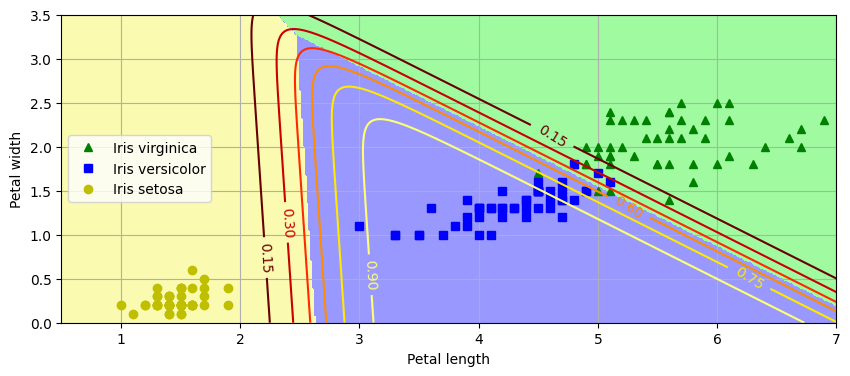

In [43]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()

## Exercises

1. Which linear regression training algorithm can you use if you have a training set with millions of features?

   - Stochastic Gradient Descent
     - Updates weights using one training example (a random row in dataset) at a time
   - Mini-Batch Gradient Descent
     - Customizable batch size for number of training examples per iteration

2. Suppose the feature in your training set have very different scales. Which algorithms might suffer from this, and how? What can you do about it?

   - Gradient Descent
     - Cost function contours become very elongated
     - Convergence becomes extremely slow
   - Regularized linear models
     - Small-scale feature requires a larger weight to have the same effect as a large-scale feature
     - Ridge penalizes large weights more heavily, so the small-scale feature gets punished unfairly. Model becomes biased toward large-scale features.
     - Lasso also penalizes large weights more heavily, more likely to zero-out small-scale features

   To solve this, should ensure all features have a similar scale, for example, by using Scikit-Learn's StandardScaler class as shown below.

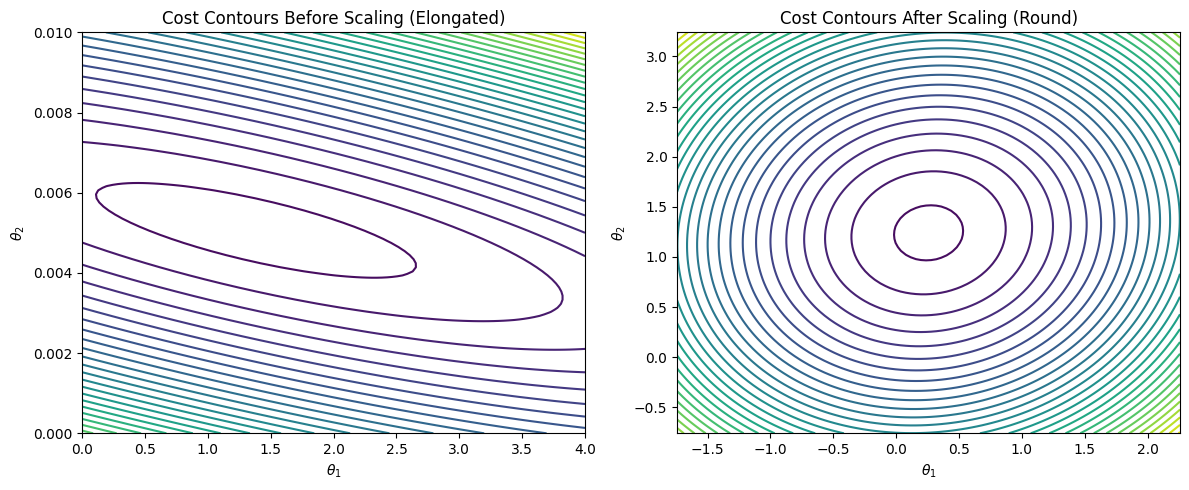

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
m = 100

# Feature 1: small range (0–1)
x1 = np.random.rand(m)

# Feature 2: large range (0–1000)
x2 = np.random.rand(m) * 1000

# True parameters
theta_true = np.array([2, 0.005])
y = theta_true[0] * x1 + theta_true[1] * x2 + np.random.randn(m) * 2

# Stack features
X = np.vstack((x1, x2)).T


# ---------------------------------------
# Cost function
# ---------------------------------------
def cost(theta1, theta2, X, y):
    preds = theta1 * X[:,0] + theta2 * X[:,1]
    return np.mean((preds - y)**2)


# ---------------------------------------
# 1) BEFORE SCALING graph
# ---------------------------------------
theta1_vals = np.linspace(0, 4, 100)
theta2_vals = np.linspace(0, 0.01, 100)
T1, T2 = np.meshgrid(theta1_vals, theta2_vals)

J = np.zeros_like(T1)
for i in range(len(theta1_vals)):
    for j in range(len(theta2_vals)):
        J[j,i] = cost(theta1_vals[i], theta2_vals[j], X, y)


# ---------------------------------------
# 2) Scale the features
# ---------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Estimate real θ values for scaled features
# Formula: θ = (X^T X)^{-1} X^T y
theta_est_scaled = np.linalg.inv(X_scaled.T @ X_scaled) @ (X_scaled.T @ y)
theta1_c, theta2_c = theta_est_scaled  # center of contour plot


# Automatically choose ranges around estimated θ
theta1_range = np.linspace(theta1_c - 2, theta1_c + 2, 100)
theta2_range = np.linspace(theta2_c - 2, theta2_c + 2, 100)

T1s, T2s = np.meshgrid(theta1_range, theta2_range)

J_scaled = np.zeros_like(T1s)
for i in range(len(theta1_range)):
    for j in range(len(theta2_range)):
        J_scaled[j,i] = cost(theta1_range[i], theta2_range[j], X_scaled, y)


# ---------------------------------------
# Plot both
# ---------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.contour(T1, T2, J, levels=30)
plt.title("Cost Contours Before Scaling (Elongated)")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

plt.subplot(1,2,2)
plt.contour(T1s, T2s, J_scaled, levels=30)
plt.title("Cost Contours After Scaling (Round)")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

plt.tight_layout()
plt.show()

3. Can gradient descent get stuck in a local minimum when training a logistic regression model?
   - Gradient descent cannot get stuck in local minima for logistic regression
   - Logistic regression cost function is convex with respect to $\theta$

The first derivative tells you the slope or gradient (rate of change) of a function, indicating if it's increasing or decreasing, while the second derivative tells you the concavity (how the slope changes), revealing if the curve bends upward (convex) or downward (concave). A positive second derivative means convex, while a negative one means concave, helping identify local minima/maxima.
- Second derivative of logistic regression cost function w.r.t $\theta$ is always positive semi-definite
- Convex function has no local minima (only one global minimum)
- That’s why gradient descent on logistic regression cannot get stuck in local minima

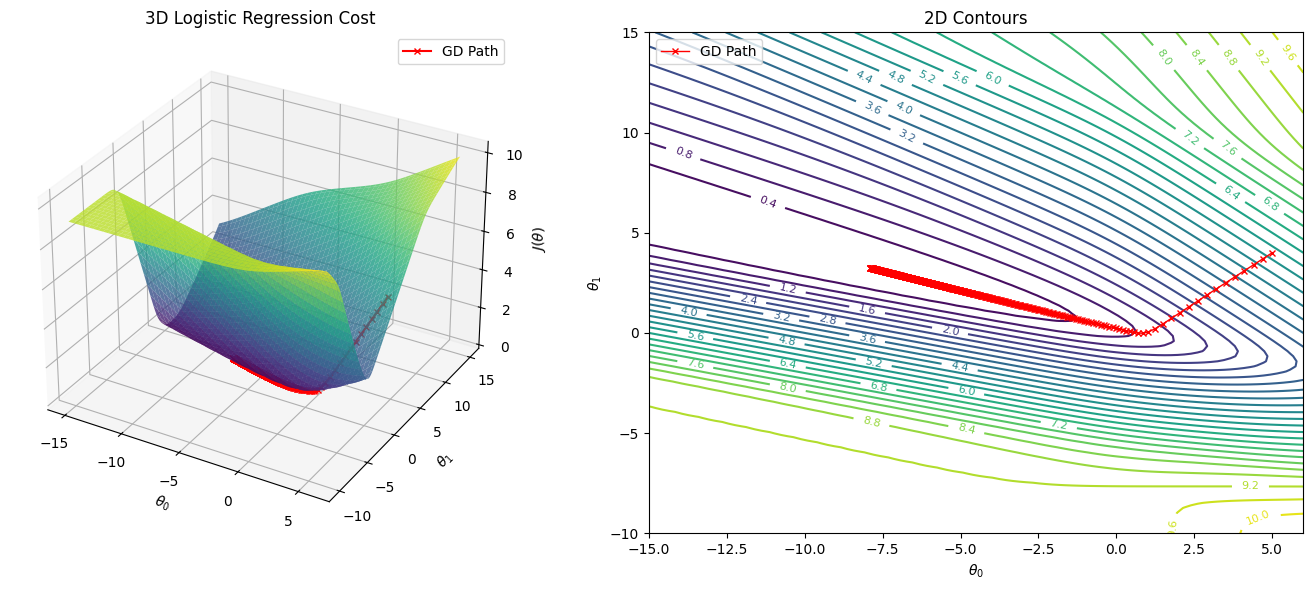

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 1. Dataset
# -----------------------------
X = np.array([0, 1, 2, 3, 4]).reshape(-1,1)
y = np.array([0, 0, 0, 1, 1])
m = len(y)
X_bias = np.hstack([np.ones((m,1)), X])  # add intercept

# -----------------------------
# 2. Sigmoid
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# 3. Logistic cost
# -----------------------------
def cost(theta):
    z = X_bias @ theta
    h = sigmoid(z)
    return -np.mean(y*np.log(h + 1e-10) + (1-y)*np.log(1-h + 1e-10))

# -----------------------------
# 4. Gradient
# -----------------------------
def gradient(theta):
    z = X_bias @ theta
    h = sigmoid(z)
    grad = (1/m) * (X_bias.T @ (h - y))
    return grad

# -----------------------------
# 5. Gradient Descent
# -----------------------------
theta = np.array([5.0, 4.0])  # start point
alpha = 0.5                   # learning rate
iterations = 500

path = [theta.copy()]

for i in range(iterations):
    theta -= alpha * gradient(theta)
    path.append(theta.copy())

path = np.array(path)

# -----------------------------
# 6. Cost surface for visualization
# -----------------------------
theta0_vals = np.linspace(-15, 6, 100)
theta1_vals = np.linspace(-10, 15, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([theta0_vals[i], theta1_vals[j]])
        J_vals[j,i] = cost(t)

# -----------------------------
# 7. Plot 3D surface + GD path
# -----------------------------
fig = plt.figure(figsize=(14,6))

# 3D surface
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax1.plot(path[:,0], path[:,1], [cost(t) for t in path], 'rx-', label='GD Path', markersize=5)
ax1.set_xlabel(r'$\theta_0$')
ax1.set_ylabel(r'$\theta_1$')
ax1.set_zlabel(r'$J(\theta)$')
ax1.set_title('3D Logistic Regression Cost')
ax1.legend()

# -----------------------------
# 8. Plot 2D contour + GD path
# -----------------------------
ax2 = fig.add_subplot(1,2,2)
contours = ax2.contour(T0, T1, J_vals, levels=30)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(path[:,0], path[:,1], 'rx-', label='GD Path', markersize=4, linewidth=1)
ax2.set_xlabel(r'$\theta_0$')
ax2.set_ylabel(r'$\theta_1$')
ax2.set_title('2D Contours')
ax2.legend()

plt.tight_layout()
plt.show()

4. Do all gradient descent algorithms lead to the samel model, provided you let them run long enough?
   - All gradient descent algorithms will converge to the same model if all of the following are true:
     - Cost function is convex (eg. linear regression and logistic regression)
     - Learning rate is small enough to ensure convergence. Gradually reducing the learning rate over time for SGD and Mini-Batch GD.
     - Non-convex cost function will not lead to the same model as there are multiple local minima

5. Suppose you use batch gradient descent and you plot the validation error at every epoch. If you notice that the validation error consistently goes up, what is likely going on? How can you fix this?
   - If training loss decreases smoothly while validation loss rises, the model could be overfitting.
   - To prevent overfitting, apply early stopping or add $\ell_1$, $\ell_2$ regularization
   - Another possibility is that the learning rate is too high and the algorithm is diverging. Can verify by checking whether the training loss is also increasing.

6. Is it a good idea to stop mini-batch gradient descent immediately when the validation error goes up?
   - Mini-batch GD is noisy by nature, where each update uses only a subset of the data
   - Immediately stop training when the validation error goes up, you may stop much too early, before the optimum is reached
   - A better option is to save the model with the lowest validation error, if there is no improvement for a long period of time, can always revert to the best saved model

7. Which gradient descent algorithm (among those we discussed) will reach the vicinity of the optimal solution the fastest? Which will actually converge? How can you make the others converge as well?
   - SGD will reach the vicinity of the optimal solution the fastest as it only train one instace at a time.
   - Only Batch GD will converge
   - SGD and Mini-Batch GD will bounce around the minimum, for them to converge, gradually reduce the learning rate

8. Suppose you are using polynomial regression. You plot the learning curves and you notice that there is a large gap between the training error and the validation error. What is happening? What are three ways to solve this?
   - If the validation error is much higher than the training error, is indicating that the model is overfitting
   - Reduce the polynomial degree
   - Add $\ell_1$ or $\ell_2$ regularization to the cost function
   - Increase the size of training data set

9. Suppose you are using ridge regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter $\alpha$ or reduce it?
   - If both training error and validation error are almost equal and fairly high, it means the model suffers from high bias (How wrong are you on average?)
   - Ridge regression is used to prevent overfitting by reducing variance and increasing bias. The $\alpha$ is used to control the regularization strength, hence, in this case, the hyperparameter should be reduced

10. Why would you want to use:

    a. Ridge regression instead of plain linear regression (i.e., without any regularization)?
       - Regression reduces overfitting by increasing bias, any model with regularization typically performs better than plain linear regression

    b. Lasso instead of ridge regression
       - lasso regression eliminates the weights of the least important features
       - ridge regression makes weights smaller, but don’t remove any features
       - lasso regression is useful when you have many features but only a few matter
       - but if you are unsure of which features are not important, you should perform ridge regression instead

    c. Elastic net instead of lasso
       - lasso may behave eratically when:
         - number of features greater than the number of training instance
         - several features are strongly crrelated
       - add an extra hyperparameter to tune. If you want Lasso without the erratic behavior, you can just use Elastic Net with an ℓ1 ratio close to 1

11. Suppose you want to classify pictures as outdoor/indoor and daytime/nighttime. Should you implement two logistic regression classifiers or one softmax regression classifier?
    - Use two logistic regression classifiers, because indoor/outdoor and day/night are independent labels, not mutually exclusive classes.
    - An image can be:
      - Indoor + Day
      - Indoor + Night
      - Outdoor + Day
      - Outdoor + Night
      
      So multiple labels can be true at the same time.

12. Implement batch gradient descent with early stopping for softmax regression without using Scikit-Learn, only NumPy. Use it on a classification task such as the iris dataset.

In [46]:
import numpy as np
from sklearn.datasets import load_iris

# -----------------------------
# Load data
# -----------------------------
iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

# Add bias term to let the model shift the decision boundary or line, instead of forcing it to pass through the origin.
X_with_bias = np.c_[np.ones(len(X)), X]

In [47]:
# -----------------------------
# Train / Val / Test split
# -----------------------------
np.random.seed(42)  # reproducibility

m = len(X_with_bias)
indices = np.random.permutation(m)

# Split ratios
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_end = int(train_ratio * m)
val_end = train_end + int(val_ratio * m)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

X_train = X_with_bias[train_idx]
y_train = y[train_idx]

X_valid = X_with_bias[val_idx]
y_valid = y[val_idx]

X_test = X_with_bias[test_idx]
y_test = y[test_idx]

In [48]:
# -----------------------------
# One-hot encoding
# -----------------------------
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

# Test with first 5 data
print("Target Class:", y_train[:5])
print("\nOne-hot Encoding:\n", to_one_hot(y_train[:5]))

Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

Target Class: [1 0 2 1 1]

One-hot Encoding:
 [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [49]:
# -----------------------------
# Feature scaling
# -----------------------------
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

- X_train[:, 1:] → all features except the bias column (x_0 = 1)
- .mean(axis=0) → compute mean of each feature column

$$
\begin{aligned}
\hat p_k &= \sigma(s(x))_k \\
&= \frac{exp(s_k(x))}{\sum_{j=1}^K exp(s_j(x))}
\end{aligned}
$$

In [50]:
# -----------------------------
# Implement Softmax function
# -----------------------------
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums

In [51]:
n_inputs = X_train.shape[1]           # 2 features plus the bias term
n_outputs = len(np.unique(y_train))   # 3 classes

In [52]:
# -----------------------------
# Softmax regression with BGD
# -----------------------------
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)

    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        print(epoch, xentropy_losses.sum(axis=1).mean())

    # Batch Gradient Descent
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    Theta = Theta - eta * gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


In [53]:
# Predictions for the validation set
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_pred = np.argmax(Y_proba, axis=1)

accuracy_score = np.mean(y_pred == y_valid)
print(accuracy_score)

0.9333333333333333


In [54]:
# -----------------------------
# Add ℓ2 regularization
# -----------------------------
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5
alpha = 0.05  # regularization hyperparameter

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)

    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
        total_loss = xentropy_losses.sum(axis=1).mean() + alpha * l2_loss
        print(epoch, total_loss.round(4))

    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.8519
1000 0.5117
2000 0.5117
3000 0.5117
4000 0.5117
5000 0.5117


- Loss is greater due to additional $\ell_2$ penalty
- Test to see whether the regularization term will improve the model

In [55]:
# Predictions for the validation set
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_pred = np.argmax(Y_proba, axis=1)

accuracy_score = np.mean(y_pred == y_valid)
print(accuracy_score)

0.9333333333333333


In [56]:
# -----------------------------
# Early Stopping
# -----------------------------
eta = 0.5
n_epochs = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100  # regularization hyperparameter
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))
    if total_loss < best_loss:
        best_loss = total_loss
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "early stopping!")
        break
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
281 0.3256
282 0.3256 early stopping!


In [57]:
# Predictions for the validation set
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_pred = np.argmax(Y_proba, axis=1)

accuracy_score = np.mean(y_pred == y_valid)
print(accuracy_score)

0.9333333333333333


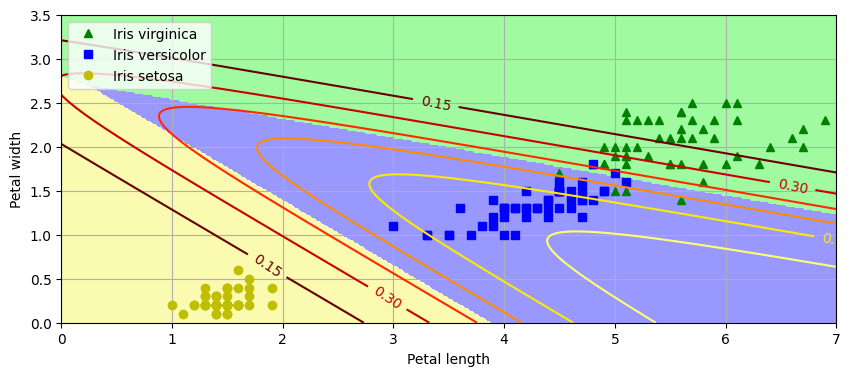

In [58]:
# Plot the model's predictions on the whole dataset

custom_cmap = mpl.colors.ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()
plt.show()

In [59]:
# -----------------------------
# Test Set
# -----------------------------
logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
print(accuracy_score)

0.9666666666666667


Well we get even better performance on the test set. This variability is likely due to the very small size of the dataset: depending on how you sample the training set, validation set and the test set, you can get quite different results.